# Dataset Preparation

In [3]:
import pandas as pd

file_path = "Domestic Interest Rates.csv"

# Skip the first few rows
df_raw = pd.read_csv(file_path, header=1)

df_raw.head()

,DATE,Unnamed: 1,Unnamed: 2,PUBLICATION,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,SORA TRANSACTIONS,TRANSACTED,TRANSACTED.1,CALCULATION
0,NaN,NaN,NaN,DATE,NaN,NaN,1-MONTH,3-MONTH,6-MONTH,(S$ MILLIONS),RATE,RATE,METHOD
1,2013.0,Jan,2.0,3-Jan-13,0.0189,0.963261,0.051,0.0576,0.0685,--,--,--,--
2,NaN,NaN,3.0,4-Jan-13,0.0194,0.963261,0.0485,0.0576,0.0685,--,--,--,--
3,NaN,NaN,4.0,7-Jan-13,0.0228,0.963263,0.0442,0.0577,0.0683,--,--,--,--
4,NaN,NaN,7.0,8-Jan-13,0.0285,0.963264,0.0444,0.0579,0.0682,--,--,--,--


## Rename columns & fill rows

In [4]:
df_raw.columns = [
    "Year", "Month", "Day",
    "Publication Date",
    "SORA",
    "SORA Index",
    "SORA_1M",
    "SORA_3M",
    "SORA_6M",
    "Volume",
    "High",
    "Low",
    "Method"
]

df_raw["Year"] = df_raw["Year"].ffill()
df_raw["Month"] = df_raw["Month"].ffill()
df_raw["Day"] = pd.to_numeric(df_raw["Day"], errors="coerce")
df_raw = df_raw[df_raw["Day"].notna()]
df_raw["Day"] = df_raw["Day"].astype(int)
df_raw["Year"] = df_raw["Year"].astype(int)
df_raw = df_raw.reset_index(drop=True)
df_raw.head(5)

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,High,Low,Method
0,2013,Jan,2,3-Jan-13,0.0189,0.963261,0.051,0.0576,0.0685,--,--,--,--
1,2013,Jan,3,4-Jan-13,0.0194,0.963261,0.0485,0.0576,0.0685,--,--,--,--
2,2013,Jan,4,7-Jan-13,0.0228,0.963263,0.0442,0.0577,0.0683,--,--,--,--
3,2013,Jan,7,8-Jan-13,0.0285,0.963264,0.0444,0.0579,0.0682,--,--,--,--
4,2013,Jan,8,9-Jan-13,0.0327,0.963265,0.0446,0.0579,0.0681,--,--,--,--


## Create a proper datetime column

In [5]:
date_str = (
    df_raw["Year"].astype(str) + "-" +
    df_raw["Month"] + "-" +
    df_raw["Day"].astype(str)
)

df_raw["Date"] = pd.to_datetime(date_str, errors="coerce")

cols = ["SORA", "SORA Index", "SORA_1M", "SORA_3M", "SORA_6M", "Volume", "High", "Low"]

for col in cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

df_raw.tail()

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,High,Low,Method,Date
3308,2026,Mar,11,12-Mar-26,1.0022,1.117504,1.0426,1.1055,1.1582,1496.0,1.10,0.55,Normal,2026-03-11
3309,2026,Mar,12,13-Mar-26,0.8864,1.117531,1.0387,1.1023,1.1555,3423.0,1.20,0.50,Normal,2026-03-12
3310,2026,Mar,13,16-Mar-26,0.8809,1.117612,1.0205,1.0926,1.1472,1887.0,1.25,0.50,Normal,2026-03-13
3311,2026,Mar,16,17-Mar-26,0.9103,1.117640,1.0141,1.0887,1.1460,1791.0,1.25,0.50,Normal,2026-03-16
3312,2026,Mar,17,18-Mar-26,0.9394,1.117668,1.0087,1.0851,1.1450,2144.0,1.25,0.50,Normal,2026-03-17


In [6]:
print(df_raw.head(20))
print(df_raw.columns)

    Year Month  Day Publication Date    SORA  SORA Index  SORA_1M  SORA_3M  \
0   2013   Jan    2         3-Jan-13  0.0189    0.963261   0.0510   0.0576   
1   2013   Jan    3         4-Jan-13  0.0194    0.963261   0.0485   0.0576   
2   2013   Jan    4         7-Jan-13  0.0228    0.963263   0.0442   0.0577   
3   2013   Jan    7         8-Jan-13  0.0285    0.963264   0.0444   0.0579   
4   2013   Jan    8         9-Jan-13  0.0327    0.963265   0.0446   0.0579   
5   2013   Jan    9        10-Jan-13  0.0202    0.963265   0.0445   0.0578   
6   2013   Jan   10        11-Jan-13  0.0247    0.963266   0.0444   0.0577   
7   2013   Jan   11        14-Jan-13  0.0224    0.963268   0.0441   0.0575   
8   2013   Jan   14        15-Jan-13  0.0235    0.963268   0.0434   0.0575   
9   2013   Jan   15        16-Jan-13  0.0274    0.963269   0.0429   0.0575   
10  2013   Jan   16        17-Jan-13  0.0266    0.963270   0.0423   0.0572   
11  2013   Jan   17        18-Jan-13  0.0255    0.963271   0.039

### Add Fx & Fed datasets

In [7]:
fx = pd.read_csv("Exchange Rates.csv", skiprows=6)
fed = pd.read_csv("chart_20260318T123749.csv")

In [8]:
print(fx.head())
print(fx.columns)

print(fed.head())
print(fed.columns)

  End of Period Unnamed: 1  Unnamed: 2 S$ Per Unit of Euro  \
0          2013        Jan         2.0              1.6221   
1           NaN        NaN         3.0              1.6060   
2           NaN        NaN         4.0              1.6020   
3           NaN        NaN         7.0              1.6063   
4           NaN        NaN         8.0              1.6126   

  S$ Per Unit of Pound Sterling S$ Per Unit of US Dollar  
0                        1.9960                   1.2208  
1                        1.9825                   1.2227  
2                        1.9757                   1.2296  
3                        1.9752                   1.2307  
4                        1.9795                   1.2289  
Index(['End of Period', 'Unnamed: 1', 'Unnamed: 2', 'S$ Per Unit of Euro',
       'S$ Per Unit of Pound Sterling', 'S$ Per Unit of US Dollar'],
      dtype='object')
         Date  Value
0  07/01/1954   1.13
1  07/02/1954   1.25
2  07/03/1954   1.25
3  07/04/1954   1.25
4 

In [9]:
fx.columns = [
    "Year", "Month", "Day",
    "EUR_SGD",
    "GBP_SGD",
    "USD_SGD"
]

fx["Year"] = fx["Year"].ffill()
fx["Month"] = fx["Month"].ffill()

fx.head()

,Year,Month,Day,EUR_SGD,GBP_SGD,USD_SGD
0,2013,Jan,2.0,1.6221,1.9960,1.2208
1,2013,Jan,3.0,1.6060,1.9825,1.2227
2,2013,Jan,4.0,1.6020,1.9757,1.2296
3,2013,Jan,7.0,1.6063,1.9752,1.2307
4,2013,Jan,8.0,1.6126,1.9795,1.2289


In [10]:
fx["Day"] = pd.to_numeric(fx["Day"], errors="coerce")
fx = fx[fx["Day"].notna()]
fx["Day"] = fx["Day"].astype(int)
fx["Year"] = fx["Year"].astype(int)

In [11]:
fx["Date"] = pd.to_datetime(
    fx["Year"].astype(str) + "-" +
    fx["Month"].astype(str) + "-" +
    fx["Day"].astype(str),
    errors="coerce"
)

fx.head()

,Year,Month,Day,EUR_SGD,GBP_SGD,USD_SGD,Date
0,2013,Jan,2,1.6221,1.9960,1.2208,2013-01-02
1,2013,Jan,3,1.6060,1.9825,1.2227,2013-01-03
2,2013,Jan,4,1.6020,1.9757,1.2296,2013-01-04
3,2013,Jan,7,1.6063,1.9752,1.2307,2013-01-07
4,2013,Jan,8,1.6126,1.9795,1.2289,2013-01-08


In [12]:
for col in ["EUR_SGD", "GBP_SGD", "USD_SGD"]:
    fx[col] = pd.to_numeric(fx[col], errors="coerce")

In [13]:
fx = fx.drop(columns=["Year", "Month", "Day"])
fx = fx.sort_values("Date").reset_index(drop=True)

In [14]:
fed = fed.rename(columns={
    "Date": "Date",
    "Value": "FedRate"
})

fed["Date"] = pd.to_datetime(fed["Date"], format="%m/%d/%Y")
fed["FedRate"] = pd.to_numeric(fed["FedRate"], errors="coerce")

fed = fed.sort_values("Date")

In [15]:
df = df_raw.copy()

# Merge FX
df = df.merge(fx, on="Date", how="left")

# Merge Fed
df = df.merge(fed, on="Date", how="left")

# Fill missing macro values
df = df.sort_values("Date").ffill()

df.tail()

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,High,Low,Method,Date,EUR_SGD,GBP_SGD,USD_SGD,FedRate
3308,2026,Mar,11,12-Mar-26,1.0022,1.117504,1.0426,1.1055,1.1582,1496.0,1.10,0.55,Normal,2026-03-11,1.4785,1.7100,1.2713,3.64
3309,2026,Mar,12,13-Mar-26,0.8864,1.117531,1.0387,1.1023,1.1555,3423.0,1.20,0.50,Normal,2026-03-12,1.4726,1.7065,1.2762,3.64
3310,2026,Mar,13,16-Mar-26,0.8809,1.117612,1.0205,1.0926,1.1472,1887.0,1.25,0.50,Normal,2026-03-13,1.4718,1.7067,1.2789,3.64
3311,2026,Mar,16,17-Mar-26,0.9103,1.117640,1.0141,1.0887,1.1460,1791.0,1.25,0.50,Normal,2026-03-16,1.4670,1.6989,1.2812,3.64
3312,2026,Mar,17,18-Mar-26,0.9394,1.117668,1.0087,1.0851,1.1450,2144.0,1.25,0.50,Normal,2026-03-17,1.4699,1.7013,1.2790,3.64


Add Day of Week as a variable

In [16]:
df["dayofweek"]   = df["Date"].dt.dayofweek        # 0=Mon 4=Fri
df["is_monday"]   = (df["dayofweek"] == 0).astype(int)
df["is_friday"]   = (df["dayofweek"] == 4).astype(int)
df["month"]       = df["Date"].dt.month
df["is_month_end"]= df["Date"].dt.is_month_end.astype(int)
df["quarter"]     = df["Date"].dt.quarter

In [17]:
df["SORA_change"] = df["SORA"].diff()
df.head(10)

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,...,GBP_SGD,USD_SGD,FedRate,dayofweek,is_monday,is_friday,month,is_month_end,quarter,SORA_change
0,2013,Jan,2,3-Jan-13,0.0189,0.963261,0.0510,0.0576,0.0685,NaN,...,1.9960,1.2208,0.17,2,0,0,1,0,1,NaN
1,2013,Jan,3,4-Jan-13,0.0194,0.963261,0.0485,0.0576,0.0685,NaN,...,1.9825,1.2227,0.17,3,0,0,1,0,1,0.0005
2,2013,Jan,4,7-Jan-13,0.0228,0.963263,0.0442,0.0577,0.0683,NaN,...,1.9757,1.2296,0.16,4,0,1,1,0,1,0.0034
3,2013,Jan,7,8-Jan-13,0.0285,0.963264,0.0444,0.0579,0.0682,NaN,...,1.9752,1.2307,0.16,0,1,0,1,0,1,0.0057
4,2013,Jan,8,9-Jan-13,0.0327,0.963265,0.0446,0.0579,0.0681,NaN,...,1.9795,1.2289,0.15,1,0,0,1,0,1,0.0042
5,2013,Jan,9,10-Jan-13,0.0202,0.963265,0.0445,0.0578,0.0681,NaN,...,1.9702,1.2281,0.14,2,0,0,1,0,1,-0.0125
6,2013,Jan,10,11-Jan-13,0.0247,0.963266,0.0444,0.0577,0.0681,NaN,...,1.9648,1.2268,0.14,3,0,0,1,0,1,0.0045
7,2013,Jan,11,14-Jan-13,0.0224,0.963268,0.0441,0.0575,0.0679,NaN,...,1.9771,1.2242,0.14,4,0,1,1,0,1,-0.0023
8,2013,Jan,14,15-Jan-13,0.0235,0.963268,0.0434,0.0575,0.0678,NaN,...,1.9806,1.2261,0.14,0,1,0,1,0,1,0.0011
9,2013,Jan,15,16-Jan-13,0.0274,0.963269,0.0429,0.0575,0.0678,NaN,...,1.9695,1.2245,0.15,1,0,0,1,0,1,0.0039


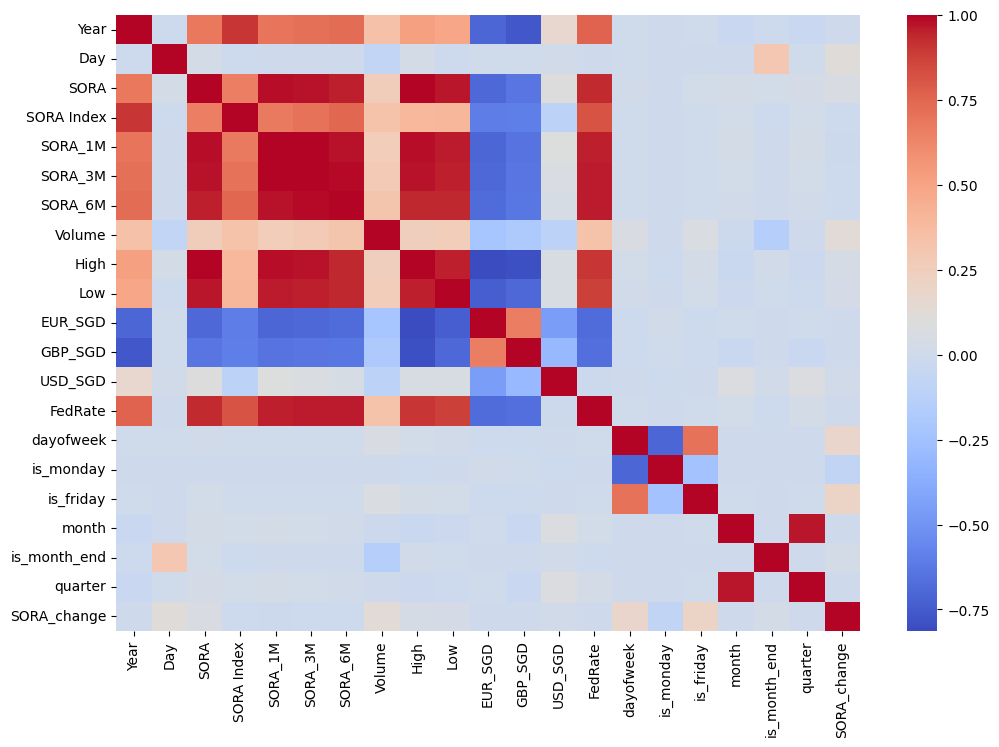

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.show()

## Data Exploration 

In [19]:
df["SORA"].describe()
df["SORA_change"] = df["SORA"].diff()
df["SORA_change"].describe()

count    3312.000000
mean        0.000278
std         0.151161
min        -1.262600
25%        -0.053725
50%         0.000500
75%         0.051900
max         1.482300
Name: SORA_change, dtype: float64

In [20]:
df["SORA_change"].skew()

np.float64(0.16492764464861878)

SORA changes feature a low mean but huge difference between min and max while skew is positive - rare but large spikes, upward movements tend to be more extreme than downward ones

In [21]:
df["SORA"].autocorr(lag=1)
df["SORA"].autocorr(lag=2)
df["SORA_change"].autocorr(lag=1)

np.float64(-0.06261785140102838)

Small, negative correlation - if SORA goes up today it's slightly more likely to go down the next day

<Axes: >

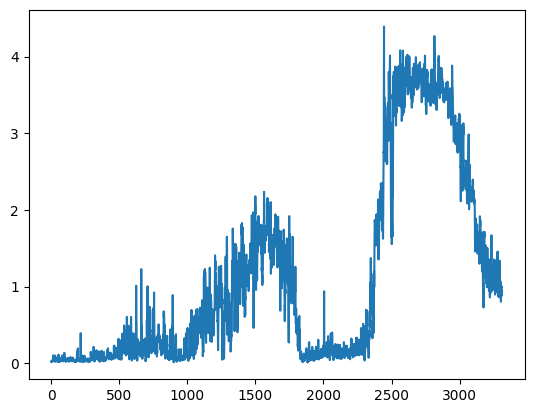

In [22]:
df["SORA"].plot()

<Axes: >

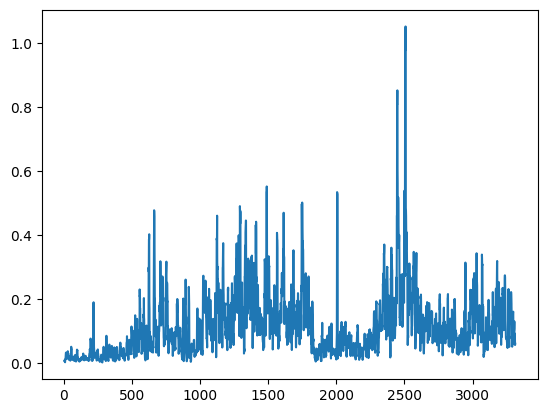

In [23]:
df["volatility"] = df["SORA_change"].rolling(5).std()
df["volatility"].plot()

In [24]:
df["range"] = df["High"] - df["Low"]
df["range"].describe()

count    1412.000000
mean        0.829060
std         0.538852
min         0.050000
25%         0.347250
50%         0.800000
75%         1.100000
max         2.750000
Name: range, dtype: float64

<Axes: >

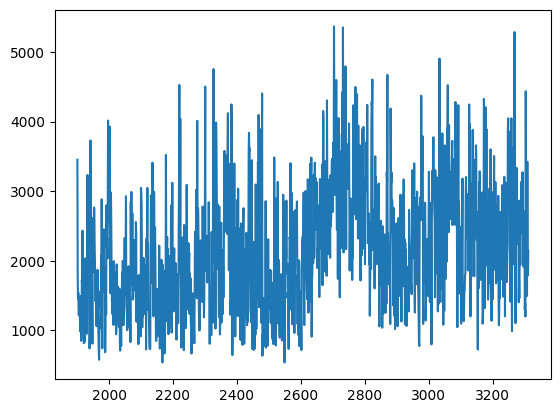

In [25]:
df["Volume"].describe()
df["Volume"].plot()

In [26]:
df[["SORA", "Volume"]].corr()

,SORA,Volume
SORA,1.000000,0.252738
Volume,0.252738,1.000000


0.25 correlation - weak to medium predictive power. 

In [27]:
df[["SORA", "range"]].corr()

,SORA,range
SORA,1.000000,0.755187
range,0.755187,1.000000


Surprisingly high positive correlation - this indicates liquidity stress is a primary driver of the national rate movements. 

In [28]:
df.groupby("dayofweek")["SORA_change"].mean()

dayofweek
0   -0.025125
1   -0.021063
2   -0.015225
3    0.001196
4    0.062349
Name: SORA_change, dtype: float64

Monday to wednesday negative, friday stands out positive even though its still a low predictive power. This could mean they're borrowing more for the weekends? Since banks are closed they borrow more to cover 3 days of exposure (sat, sun, mon). 

In [29]:
import scipy.stats as stats

fri = df[df["dayofweek"] == 4]["SORA_change"]
others = df[df["dayofweek"] != 4]["SORA_change"]

stats.ttest_ind(fri, others, nan_policy="omit")

TtestResult(statistic=np.float64(11.959492476379411), pvalue=np.float64(2.656180519703688e-32), df=np.float64(3310.0))

pvalue for "friday effect" is 2.6e-32. It's real even though the predictive power is low. 

In [30]:
groups = [
    df[df["dayofweek"] == i]["SORA_change"].dropna()
    for i in range(5)
]

import scipy.stats as stats
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(38.923591994383784), pvalue=np.float64(6.921372782426744e-32))

pvalue 6.9e-32. ANOVA discerns at least one weekday is radically different for mean SORA change. 

In [31]:
threshold = df["SORA_change"].std() * 2
spikes = df[df["SORA_change"].abs() > threshold]
spikes.tail(10)

,Year,Month,Day,Publication Date,SORA,SORA Index,SORA_1M,SORA_3M,SORA_6M,Volume,...,FedRate,dayofweek,is_monday,is_friday,month,is_month_end,quarter,SORA_change,volatility,range
3029,2025,Jan,31,3-Feb-25,2.6325,1.098051,2.7985,2.8993,3.1468,1273.0,...,4.33,4,0,1,1,1,1,-0.4958,0.343460,0.90
3068,2025,Mar,27,28-Mar-25,2.3592,1.101939,2.4144,2.5618,2.8404,2599.0,...,4.33,3,0,0,3,0,1,-0.6237,0.339341,0.55
3148,2025,Jul,23,24-Jul-25,1.8136,1.108906,1.5619,1.8675,2.1581,3659.0,...,4.33,2,0,0,7,0,3,0.3572,0.221920,0.95
3176,2025,Sep,1,2-Sep-25,0.7261,1.110662,1.3354,1.5488,1.9134,2118.0,...,4.33,0,1,0,9,0,3,-0.3135,0.174317,0.80
3178,2025,Sep,3,4-Sep-25,1.4808,1.110736,1.3111,1.5320,1.9002,4206.0,...,4.33,2,0,0,9,0,3,0.5493,0.309233,1.10
3190,2025,Sep,19,22-Sep-25,1.5372,1.111532,1.2957,1.4879,1.8166,3035.0,...,4.08,4,0,1,9,0,3,0.4243,0.244298,1.40
3220,2025,Nov,3,4-Nov-25,1.0306,1.113176,1.2448,1.3143,1.5717,1076.0,...,3.87,0,1,0,11,0,4,-0.3209,0.235070,0.70
3235,2025,Nov,24,25-Nov-25,1.2670,1.113906,1.1527,1.2434,1.4491,1574.0,...,3.88,0,1,0,11,0,4,-0.4015,0.266032,0.80
3261,2025,Dec,31,2-Jan-26,0.8949,1.115252,1.1739,1.1857,1.3195,988.0,...,3.64,2,0,0,12,1,4,-0.4263,0.205646,0.70
3282,2026,Jan,30,2-Feb-26,1.1092,1.116330,1.1382,1.1502,1.2384,1404.0,...,3.64,4,0,1,1,0,1,-0.3461,0.221989,0.70


190 spikes across 3312 observations - 5.7%. SORA has somewhat frequent extreme movements relative to normal distribution.

In [32]:
spikes["dayofweek"].value_counts(normalize=True)

dayofweek
4    0.268421
3    0.236842
0    0.178947
1    0.173684
2    0.142105
Name: proportion, dtype: float64

In [33]:
df["dayofweek"].value_counts(normalize=True)

dayofweek
3    0.203139
1    0.202535
2    0.200724
4    0.197102
0    0.196499
Name: proportion, dtype: float64

In [34]:
from scipy.stats import chisquare

observed = spikes["dayofweek"].value_counts().sort_index()
expected = df["dayofweek"].value_counts().sort_index() * (len(spikes) / len(df))

chisquare(observed, expected)

Power_divergenceResult(statistic=np.float64(10.296849085371937), pvalue=np.float64(0.03571342303074251))

chisq = 10.29 and pvalue = 0.03, statistically significant. Spike occurence depends on day of week. 

In [35]:
positive_spikes = spikes[spikes["SORA_change"] > 0]
negative_spikes = spikes[spikes["SORA_change"] < 0]
positive_spikes["dayofweek"].value_counts(normalize=True)


dayofweek
4    0.467391
3    0.239130
0    0.108696
1    0.108696
2    0.076087
Name: proportion, dtype: float64

In [36]:
negative_spikes["dayofweek"].value_counts(normalize=True)

dayofweek
0    0.244898
1    0.234694
3    0.234694
2    0.204082
4    0.081633
Name: proportion, dtype: float64

In [40]:
pos = df[df["SORA_change"] > 0]["SORA_change"]
neg = df[df["SORA_change"] < 0]["SORA_change"]

pos.mean(), neg.mean(), pos.std(), neg.std()

(np.float64(0.0935032354703415),
 np.float64(-0.09476872327428221),
 np.float64(0.1196830531652043),
 np.float64(0.1171926497300613))

In [41]:
large_moves = df[df["SORA_change"].abs() > df["SORA_change"].std()]

large_moves["SORA_change"].shift(-1).corr(large_moves["SORA_change"])

np.float64(-0.19342738884576352)

In [42]:
df["volatility"] = df["SORA_change"].rolling(5).std()

df[["SORA", "volatility"]].corr()

,SORA,volatility
SORA,1.000000,0.319569
volatility,0.319569,1.000000


In [43]:
df.groupby("dayofweek")["SORA_change"].std()

dayofweek
0    0.147889
1    0.136473
2    0.129108
3    0.161204
4    0.161683
Name: SORA_change, dtype: float64

In [44]:
spikes["SORA_change"].describe()

count    190.000000
mean      -0.003113
std        0.480090
min       -1.262600
25%       -0.401450
50%       -0.305100
75%        0.406625
max        1.482300
Name: SORA_change, dtype: float64

In [45]:
df[["SORA_change", "range"]].corr()

,SORA_change,range
SORA_change,1.000000,0.032515
range,0.032515,1.000000


In [38]:
spikes = df[df["SORA_change"].abs() > threshold]
normal = df[df["SORA_change"].abs() <= threshold]

spikes[["Volume", "range"]].mean()
normal[["Volume", "range"]].mean()

Volume    2151.937594
range        0.798453
dtype: float64

In [39]:
from statsmodels.tsa.stattools import adfuller

adfuller(df["SORA_change"].dropna())

(np.float64(-16.08083945047278),
 np.float64(5.380617782173913e-29),
 27,
 3284,
 {'1%': np.float64(-3.4323428193711396),
  '5%': np.float64(-2.8624205094378947),
  '10%': np.float64(-2.567238713568611)},
 np.float64(-3332.128324086012))

Adfuller test pvalue of 5.3^e-29. SORA changes are strongly stationary.